# Capítulo 9-10: Desafíos, Buenas Prácticas y Pipeline Integrado *(Versión Simulada)*

## 9.1. Desafíos en la implementación

| Desafío | Descripción | Mitigación |
| :--- | :--- | :--- |
| **Calidad de los datos** | Datos incompletos generan falsos positivos/negativos. | Pipelines de calidad; validación automática. |
| **Interpretabilidad** | Modelos de DL son "cajas negras". | SHAP, LIME; modelos interpretables. |
| **Sesgo en datos** | Datos sesgados producen modelos discriminatorios. | SMOTE; revisión periódica. |
| **Ataques adversariales** | Manipulación de entradas para evadir el modelo. | Entrenamiento adversarial; monitoreo. |
| **Privacidad de datos** | Los logs contienen información sensible (GDPR, CCPA). | Anonimización; aprendizaje federado. |

## 9.2. Buenas prácticas de desarrollo seguro

1. **Controlar versiones del modelo:** usar MLflow o DVC.
2. **Separar entornos:** entrenamiento ≠ producción.
3. **Validar entradas:** sanitizar datos en producción.
4. **Monitorear deriva de datos:** Evidently AI o test KS.
5. **Reentrenar periódicamente:** el panorama de amenazas cambia.
6. **Aplicar XAI:** documentar razones de cada alerta.
7. **Gestionar secretos:** variables de entorno o bóvedas (Vault).

---
## 9.3. Monitoreo de deriva de datos en producción

Simulamos dos escenarios: datos de referencia (entrenamiento) vs datos de producción con distribución alterada.

In [1]:
# Listing 9.1: Detección de deriva de datos con estadístico KS

import numpy as np
import pandas as pd
import os
from scipy.stats import ks_2samp
from sklearn.preprocessing import LabelEncoder

def detectar_deriva(datos_referencia: pd.DataFrame,
                    datos_produccion: pd.DataFrame,
                    umbral_p: float = 0.05) -> dict:
    """
    Compara distribuciones de producción con los datos de referencia
    usando el test de Kolmogorov-Smirnov.
    """
    resultados = {}
    for columna in datos_referencia.columns:
        stat, p_valor = ks_2samp(
            datos_referencia[columna].dropna(),
            datos_produccion[columna].dropna()
        )
        hay_deriva = p_valor < umbral_p
        resultados[columna] = {
            'statistic': round(stat, 4),
            'p_value':   round(p_valor, 6),
            'deriva':    hay_deriva
        }
    columnas_con_deriva = [c for c, r in resultados.items() if r['deriva']]
    if columnas_con_deriva:
        print(f"[ALERTA] Deriva detectada en: {columnas_con_deriva}")
    else:
        print("[OK] Sin deriva significativa en los datos de entrada.")
    return resultados

# Datos de referencia
df_ref = pd.read_csv('data/network_traffic.csv').dropna()
le = LabelEncoder()
if df_ref['protocol'].dtype == object:
    df_ref['protocol'] = le.fit_transform(df_ref['protocol'])
feature_cols = ['bytes_sent', 'bytes_recv', 'duration', 'src_port']

# Simular datos de producción con deriva (distribución alterada)
np.random.seed(99)
n_prod = 1000
df_prod = pd.DataFrame({
    'bytes_sent': np.random.exponential(1200, n_prod).astype(int),
    'bytes_recv': np.random.exponential(800, n_prod).astype(int),
    'duration':   np.random.exponential(60, n_prod).round(2),
    'src_port':   np.random.randint(1024, 65535, n_prod),
})

print("=== Detección de deriva (datos simulados) ===")
resultado_deriva = detectar_deriva(df_ref[feature_cols], df_prod[feature_cols])

print(f"\n{'Columna':<15} {'Statistic':>10} {'P-value':>12} {'Deriva':>8}")
print("-" * 47)
for col, res in resultado_deriva.items():
    marca = '⚠ SÍ' if res['deriva'] else '✓ NO'
    print(f"{col:<15} {res['statistic']:>10.4f} {res['p_value']:>12.6f} {marca:>8}")

=== Detección de deriva (datos simulados) ===
[ALERTA] Deriva detectada en: ['bytes_sent', 'bytes_recv', 'duration', 'src_port']

Columna          Statistic      P-value   Deriva
-----------------------------------------------
bytes_sent          0.3213     0.000000     ⚠ SÍ
bytes_recv          0.0549     0.012151     ⚠ SÍ
duration            0.2364     0.000000     ⚠ SÍ
src_port            0.0518     0.021218     ⚠ SÍ


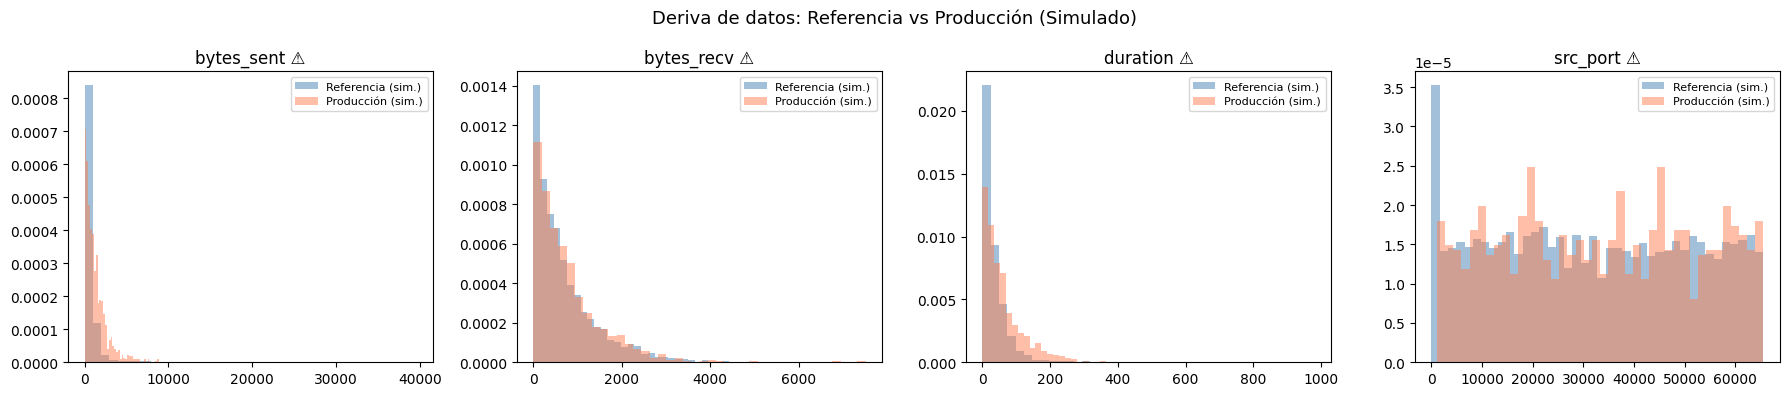

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 4))
for i, col in enumerate(feature_cols):
    axes[i].hist(df_ref[col], bins=40, alpha=0.5, color='steelblue', label='Referencia (sim.)', density=True)
    axes[i].hist(df_prod[col], bins=40, alpha=0.5, color='coral', label='Producción (sim.)', density=True)
    marca = '⚠' if resultado_deriva[col]['deriva'] else '✓'
    axes[i].set_title(f'{col} {marca}')
    axes[i].legend(fontsize=8)
plt.suptitle('Deriva de datos: Referencia vs Producción (Simulado)', fontsize=13)
plt.tight_layout()
plt.savefig('data/data_drift_analysis.png', dpi=150)
plt.show()

---
---
# Capítulo 10: Pipeline Completo de Seguridad con IA *(Versión Simulada)*

## 10.1. Arquitectura del sistema

```
Fuentes (Simuladas)  →  Ingesta       →  Análisis IA        →  Decisión      →  Acción
────────────────────    ────────────     ─────────────────     ───────────     ────────────
network_traffic.csv     Normalización    Isolation Forest      Motor reglas    Aislar sistema
file_features.csv       LabelEncoder     Random Forest         Triaje SVM      Bloquear IP
incident_data.csv       Feature Eng.     UBA Profiles          Severidad       Notificar CSIRT
```

## 10.2. Pipeline completo en Python

In [3]:
# Listing 10.1: Pipeline de seguridad integrado (sobre datos simulados)

import pandas as pd
import numpy as np
import joblib
import logging
import os
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)-8s %(message)s')

class PipelineSeguridad:
    """
    Pipeline integral de seguridad basado en IA.
    Integra detección de anomalías y clasificación de malware.
    """
    FEATURE_COLS = ['bytes_sent', 'bytes_recv', 'duration', 'src_port', 'dst_port']

    def __init__(self):
        self.scaler = MinMaxScaler()
        self.anomaly_det = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
        self.malware_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        self.entrenado = False

    def entrenar(self, df_trafico, df_malware, y_malware):
        """Entrena ambos modelos con datos históricos."""
        X_trafico = self.scaler.fit_transform(df_trafico[self.FEATURE_COLS])
        self.anomaly_det.fit(X_trafico)
        logging.info("Isolation Forest entrenado.")
        self.malware_clf.fit(df_malware, y_malware)
        logging.info("Random Forest (malware) entrenado.")
        self.entrenado = True

    def guardar(self, ruta='models/pipeline_seguridad.pkl'):
        os.makedirs(os.path.dirname(ruta), exist_ok=True)
        joblib.dump(self, ruta)
        logging.info(f"Pipeline guardado en {ruta}")

    @staticmethod
    def cargar(ruta='models/pipeline_seguridad.pkl'):
        return joblib.load(ruta)

    def analizar_trafico(self, df):
        """Detecta anomalías en tráfico de red."""
        if not self.entrenado:
            raise RuntimeError("El pipeline no ha sido entrenado.")
        X = self.scaler.transform(df[self.FEATURE_COLS])
        df = df.copy()
        df['anomalia'] = self.anomaly_det.predict(X)
        df['score_anomalia'] = self.anomaly_det.decision_function(X)
        return df

    def analizar_archivo(self, caracteristicas):
        """Clasifica un archivo como benigno o malicioso."""
        if not self.entrenado:
            raise RuntimeError("El pipeline no ha sido entrenado.")
        X = pd.DataFrame([caracteristicas])
        pred = self.malware_clf.predict(X)[0]
        proba = self.malware_clf.predict_proba(X)[0]
        return {'clasificacion':  'malicioso' if pred == 1 else 'benigno',
                'prob_benigno':   round(proba[0], 4),
                'prob_malicioso': round(proba[1], 4)}

print("[OK] Clase PipelineSeguridad definida.")

[OK] Clase PipelineSeguridad definida.


### 10.2.1. Entrenamiento con datos simulados

In [4]:
pipeline = PipelineSeguridad()

# Cargar tráfico simulado
df_trafico = pd.read_csv('data/network_traffic.csv').dropna()
le = LabelEncoder()
if df_trafico['protocol'].dtype == object:
    df_trafico['protocol'] = le.fit_transform(df_trafico['protocol'])

# Completar columna dst_port si no existe con valores del dataset
if 'dst_port' not in df_trafico.columns:
    df_trafico['dst_port'] = np.random.choice([80, 443, 53, 22], len(df_trafico))

# Cargar features PE simulados
df_malware = pd.read_csv('data/file_features.csv').dropna()
y_malware = df_malware.pop('label')

# Entrenar y guardar
pipeline.entrenar(df_trafico, df_malware, y_malware)
pipeline.guardar()

2026-05-11 22:40:48,169 INFO     Isolation Forest entrenado.


2026-05-11 22:40:48,370 INFO     Random Forest (malware) entrenado.


2026-05-11 22:40:48,428 INFO     Pipeline guardado en models/pipeline_seguridad.pkl


### 10.2.2. Análisis de tráfico en tiempo real (simulado)

In [5]:
np.random.seed(77)
n_live = 500

df_live = pd.DataFrame({
    'bytes_sent': np.concatenate([np.random.exponential(500, n_live-30).astype(int),
                                   np.random.exponential(8000, 30).astype(int)]),
    'bytes_recv': np.concatenate([np.random.exponential(800, n_live-30).astype(int),
                                   np.random.exponential(50, 30).astype(int)]),
    'duration':   np.concatenate([np.random.exponential(30, n_live-30).round(2),
                                   np.random.exponential(300, 30).round(2)]),
    'src_port':   np.concatenate([np.random.randint(1024, 65535, n_live-30),
                                   np.random.randint(1, 1024, 30)]),
    'dst_port':   np.concatenate([np.random.choice([80,443,53,22], n_live-30),
                                   np.random.choice([4444,31337,6667], 30)]),
})

resultado = pipeline.analizar_trafico(df_live)
anomalias = resultado[resultado['anomalia'] == -1]

print(f"=== Análisis de tráfico en tiempo real (simulado) ===")
print(f"Total analizados:     {len(resultado)}")
print(f"Anomalías detectadas: {len(anomalias)}")
print(f"\nTop 5 anomalías (menor score = más anómalo):")
print(anomalias.sort_values('score_anomalia').head())

=== Análisis de tráfico en tiempo real (simulado) ===
Total analizados:     500
Anomalías detectadas: 31

Top 5 anomalías (menor score = más anómalo):
     bytes_sent  bytes_recv  duration  src_port  dst_port  anomalia  \
492       12583          24    778.62       706     31337        -1   
470       10391          79    618.82       624     31337        -1   
499       15253          23    452.46       116      6667        -1   
481        9498          59    225.45       437     31337        -1   
496        9104         190    121.45       911     31337        -1   

     score_anomalia  
492       -0.217664  
470       -0.204350  
499       -0.172172  
481       -0.155899  
496       -0.152561  


### 10.2.3. Análisis de archivos ejecutables (simulado)

In [6]:
archivos_test = [
    {'nombre': 'ransomware_simulado.exe',
     'caracteristicas': {'entry_point':512,'image_base':65536,'size_of_image':15000,
                         'size_code_section':2000,'dll_flag':0,'num_sections':2,
                         'entropia_max':7.8,'entropia_media':7.2,'num_importaciones':5,
                         'num_dlls_importadas':2,'num_exportaciones':0,'file_size':25000}},
    {'nombre': 'navegador_legitimo.exe',
     'caracteristicas': {'entry_point':16384,'image_base':4194304,'size_of_image':250000,
                         'size_code_section':100000,'dll_flag':33120,'num_sections':5,
                         'entropia_max':5.2,'entropia_media':4.5,'num_importaciones':180,
                         'num_dlls_importadas':15,'num_exportaciones':3,'file_size':850000}},
]

print("=== Análisis de archivos ejecutables (simulado) ===")
for archivo in archivos_test:
    res = pipeline.analizar_archivo(archivo['caracteristicas'])
    estado = '🔴 MALICIOSO' if res['clasificacion'] == 'malicioso' else '🟢 BENIGNO'
    print(f"\n  {archivo['nombre']}")
    print(f"  → {estado}  (P={res['prob_malicioso']:.4f})")

=== Análisis de archivos ejecutables (simulado) ===

  ransomware_simulado.exe
  → 🔴 MALICIOSO  (P=1.0000)

  navegador_legitimo.exe
  → 🟢 BENIGNO  (P=0.0000)


### 10.2.4. Verificación de deriva sobre tráfico en vivo

In [7]:
feature_cols_drift = ['bytes_sent', 'bytes_recv', 'duration', 'src_port']

print("=== Verificación de deriva: Entrenamiento vs Datos en vivo ===")
resultado_drift = detectar_deriva(
    df_trafico[feature_cols_drift],
    df_live[feature_cols_drift]
)
print(f"\n{'Columna':<15} {'Statistic':>10} {'P-value':>12} {'Deriva':>8}")
print("-" * 47)
for col, res in resultado_drift.items():
    marca = '⚠ SÍ' if res['deriva'] else '✓ NO'
    print(f"{col:<15} {res['statistic']:>10.4f} {res['p_value']:>12.6f} {marca:>8}")

=== Verificación de deriva: Entrenamiento vs Datos en vivo ===
[OK] Sin deriva significativa en los datos de entrada.

Columna          Statistic      P-value   Deriva
-----------------------------------------------
bytes_sent          0.0434     0.345926     ✓ NO
bytes_recv          0.0377     0.522963     ✓ NO
duration            0.0406     0.429344     ✓ NO
src_port            0.0297     0.804115     ✓ NO


---
## 10.3. Resumen final del pipeline simulado

In [8]:
print("=" * 62)
print("  PIPELINE SIMULADO - RESUMEN FINAL")
print("=" * 62)

print("\n📁 data/  (datasets simulados generados automáticamente)")
if os.path.exists('data'):
    for f in sorted(os.listdir('data')):
        size = os.path.getsize(os.path.join('data', f))
        print(f"   {f:<42} ({size:>10,} bytes)")

print("\n📁 models/  (modelos entrenados sobre datos simulados)")
if os.path.exists('models'):
    for f in sorted(os.listdir('models')):
        size = os.path.getsize(os.path.join('models', f))
        print(f"   {f:<42} ({size:>10,} bytes)")

print("\n" + "=" * 62)
print("  Notebooks completados (versión simulada):")
for i, desc in enumerate([
    "Configuración del Entorno       (Cap. 2)",
    "Detección de Amenazas            (Cap. 3)",
    "Detección de Malware             (Cap. 4)",
    "Respuesta a Incidentes           (Cap. 5)",
    "Análisis de Comportamiento (UBA) (Cap. 6)",
    "Explicabilidad (XAI)             (Cap. 7)",
    "Ataques Adversariales            (Cap. 8)",
    "Pipeline Integrado               (Cap. 9-10)",
], 1):
    print(f"  {i:02d}. {desc}")

print("=" * 62)
print("\n[OK] Pipeline simulado completado. Todos los notebooks")
print("     pueden ejecutarse de forma independiente con datos sintéticos.")

  PIPELINE SIMULADO - RESUMEN FINAL

📁 data/  (datasets simulados generados automáticamente)
   adversarial_comparison.png                 (    33,440 bytes)
   adversarial_sensitivity.png                (    60,825 bytes)
   anomaly_detection.png                      (   113,965 bytes)
   autoencoder_loss.png                       (    31,306 bytes)
   confusion_matrix_dt.png                    (    35,616 bytes)
   confusion_matrix_rf.png                    (    34,485 bytes)
   confusion_matrix_svm_incidents.png         (    37,931 bytes)
   data_drift_analysis.png                    (    76,345 bytes)
   exploracion_trafico.png                    (    58,051 bytes)
   feature_importance.png                     (    39,841 bytes)
   file_features.csv                          (    66,455 bytes)
   incident_data.csv                          (    35,320 bytes)
   network_distribution.png                   (    32,172 bytes)
   network_traffic.csv                        (   159,062 byte